# Embeddings — Mechanistic Interpretability

Companion notebook for the ["Embeddings"](https://learnmechinterp.com/topics/embeddings/) write-up.

We use **GPT-2 small** (124M params, weight-tied, HuggingFace `transformers`) as our test model — small
enough to poke at every matrix directly, big enough to show real structure.

Sections mirror the write-up:

1. From an integer to a model state ($W_E$)
2. One token vector, many contextual meanings
3. From the residual stream back to tokens ($W_U$)
4. Weight tying
5. The direct input → output path ($W_E W_U$)
6. The embedding-only QK circuit
7. Why individual coordinates are meaningless (rotation invariance)


## 0. Setup

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

torch.manual_seed(0)

device = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"Using device: {device}")

MODEL_NAME = "gpt2"  # GPT-2 small: d_model=768, n_layer=12, n_head=12, V=50257, tied embeddings
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(device).eval()
tokenizer = GPT2TokenizerFast.from_pretrained(MODEL_NAME)

d_model = model.config.n_embd
n_layer = model.config.n_layer
n_head = model.config.n_head
d_head = d_model // n_head
V = model.config.vocab_size
print(f"d_model={d_model}  n_layer={n_layer}  n_head={n_head}  d_head={d_head}  V={V}")

Using device: mps


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

d_model=768  n_layer=12  n_head=12  d_head=64  V=50257


In [2]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [3]:
# model architecture
from torchinfo import summary

input_ids = torch.zeros((1, 10), dtype=torch.long, device=device)

summary(
    model,
    input_data=input_ids,
    device=device,
)

Layer (type:depth-idx)                             Output Shape              Param #
GPT2LMHeadModel                                    --                        --
├─GPT2Model: 1-1                                   --                        --
│    └─Embedding: 2-1                              [1, 10, 768]              38,597,376
│    └─Embedding: 2-2                              [1, 10, 768]              786,432
│    └─Dropout: 2-3                                [1, 10, 768]              --
│    └─ModuleList: 2-4                             --                        --
│    │    └─GPT2Block: 3-1                         [1, 10, 768]              7,087,872
│    │    └─GPT2Block: 3-2                         [1, 10, 768]              7,087,872
│    │    └─GPT2Block: 3-3                         [1, 10, 768]              7,087,872
│    │    └─GPT2Block: 3-4                         [1, 10, 768]              7,087,872
│    │    └─GPT2Block: 3-5                         [1, 10, 768]           

## 1. From an Integer to a Model State

A tokenizer turns text into token IDs — arbitrary integers. The **embedding matrix**
$W_E \in \mathbb{R}^{V \times d_{\text{model}}}$ replaces each ID with a learned row vector:
$\mathbf{e}_t = W_E[t, :]$.

In `transformers`, $W_E$ lives at `model.transformer.wte.weight`.

In [4]:
W_E = model.transformer.wte.weight.detach()  # (V, d_model)
W_pe = model.transformer.wpe.weight.detach()  # (n_positions, d_model) -- positional, NOT covered here
print("W_E shape:", tuple(W_E.shape))
print("W_pe shape (separate positional matrix, see 'Positional Embeddings' topic):", tuple(W_pe.shape))

text = "The bank"
ids = tokenizer(text)["input_ids"]
print(f"\n'{text}' -> token ids {ids} -> tokens {[tokenizer.decode([i]) for i in ids]}")

for t in ids:
    e_t = W_E[t]
    print(f"  id {t:>6}  {tokenizer.decode([t]):>5}  ||e_t|| = {e_t.norm():.3f}   e_t[:5] = {e_t[:5].cpu().numpy().round(3)}")

W_E shape: (50257, 768)
W_pe shape (separate positional matrix, see 'Positional Embeddings' topic): (1024, 768)

'The bank' -> token ids [464, 3331] -> tokens ['The', ' bank']
  id    464    The  ||e_t|| = 2.720   e_t[:5] = [-0.069 -0.02   0.064 -0.062 -0.114]
  id   3331   bank  ||e_t|| = 3.287   e_t[:5] = [ 0.046  0.082  0.137  0.038 -0.027]


**Pause and think (from the write-up):** if token 800 and token 801 differ by one in ID, should their
embeddings be close?

Let's check directly, instead of trusting intuition about the IDs.

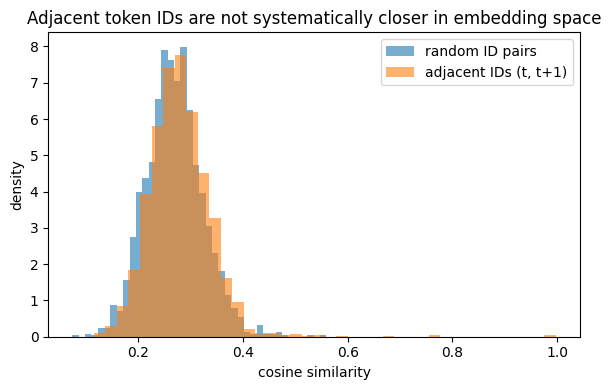

mean cos-sim, adjacent IDs: 0.2798
mean cos-sim, random pairs: 0.2686


In [5]:
rng = np.random.default_rng(0)

def cos_sim(a, b):
    return F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()

# cosine similarity between embeddings of IDs that are adjacent (t, t+1)
adjacent_sample = rng.integers(0, V - 1, size=2000)
adjacent_sims = [cos_sim(W_E[t], W_E[t + 1]) for t in adjacent_sample]

# cosine similarity between embeddings of uniformly random (unrelated) ID pairs
random_pairs = rng.integers(0, V, size=(2000, 2))
random_sims = [cos_sim(W_E[a], W_E[b]) for a, b in random_pairs]

plt.figure(figsize=(6, 4))
plt.hist(random_sims, bins=40, alpha=0.6, label="random ID pairs", density=True)
plt.hist(adjacent_sims, bins=40, alpha=0.6, label="adjacent IDs (t, t+1)", density=True)
plt.xlabel("cosine similarity")
plt.ylabel("density")
plt.title("Adjacent token IDs are not systematically closer in embedding space")
plt.legend()
plt.tight_layout()
plt.show()

print(f"mean cos-sim, adjacent IDs: {np.mean(adjacent_sims):.4f}")
print(f"mean cos-sim, random pairs: {np.mean(random_sims):.4f}")

If the write-up's claim holds, these two distributions should look essentially the same: ID order is a
tokenizer bookkeeping detail, not a geometric signal. (Any leftover difference you see is worth
interrogating — is it real, or a small-sample artifact?)

## 2. One Token Vector, Many Contextual Meanings

The row lookup for `bank` is identical every time — it's context-*independent*. What differs across
occurrences of `bank` is what attention and MLP layers build **on top of** that starting vector, once
they've seen the surrounding tokens.

We'll grab the residual stream at every layer with `output_hidden_states=True` and compare the `bank`
position in two sentences with different senses of the word.

In [ ]:
sentences = [
    "I deposited my paycheck at the bank",
    "We sat on the river bank",
]

def get_hidden_states(sentence, target_word=" bank"):
    ids = tokenizer(sentence, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**ids, output_hidden_states=True)
    # hidden_states is a tuple: (embedding_output, layer_1_output, ..., layer_N_output)
    hs = torch.stack(out.hidden_states).squeeze(1)  # (n_layer+1, seq_len, d_model)
    # find the position of the target token (assumes it appears once, as ' bank')
    target_id = tokenizer(target_word, add_special_tokens=False)["input_ids"][0]
    pos = (ids["input_ids"][0] == target_id).nonzero(as_tuple=True)[0].item()
    return hs[:, pos, :].cpu()  # (n_layer+1, d_model) -- residual stream at `bank`, every layer

hs_bank1 = get_hidden_states(sentences[0])
hs_bank2 = get_hidden_states(sentences[1])

# layer 0 = embedding-only lookup + positional term. Since 'bank' sits at a different
# position in each sentence, hs[0] differs slightly due to POSITION, not token identity.
# Compare the pure token row instead (position-free) -- this is exactly W_E[t]:
bank_id = tokenizer(" bank", add_special_tokens=False)["input_ids"][0]
print("Cosine sim of the raw embedding row W_E[bank] with itself:",
      cos_sim(W_E[bank_id], W_E[bank_id]), "(trivially 1.0 -- it's the same row both times)")

print()
for layer in range(0, n_layer + 1):
    sim = cos_sim(hs_bank1[layer], hs_bank2[layer])
    print(f"layer {layer:>2}: cos-sim(residual @ 'bank', sentence 1 vs sentence 2) = {sim:.4f}")

Cosine sim of the raw embedding row W_E[bank] with itself: 1.0000001192092896 (trivially 1.0 -- it's the same row both times)

layer  0: cos-sim(residual @ 'bank', sentence 1 vs sentence 2) = 0.9978
layer  1: cos-sim(residual @ 'bank', sentence 1 vs sentence 2) = 0.9339
layer  2: cos-sim(residual @ 'bank', sentence 1 vs sentence 2) = 0.9156
layer  3: cos-sim(residual @ 'bank', sentence 1 vs sentence 2) = 0.8720
layer  4: cos-sim(residual @ 'bank', sentence 1 vs sentence 2) = 0.8232
layer  5: cos-sim(residual @ 'bank', sentence 1 vs sentence 2) = 0.7937
layer  6: cos-sim(residual @ 'bank', sentence 1 vs sentence 2) = 0.7780
layer  7: cos-sim(residual @ 'bank', sentence 1 vs sentence 2) = 0.7859
layer  8: cos-sim(residual @ 'bank', sentence 1 vs sentence 2) = 0.7815
layer  9: cos-sim(residual @ 'bank', sentence 1 vs sentence 2) = 0.7698
layer 10: cos-sim(residual @ 'bank', sentence 1 vs sentence 2) = 0.7435
layer 11: cos-sim(residual @ 'bank', sentence 1 vs sentence 2) = 0.7972
layer 12:

The token-embedding row is identical by construction — there's nothing to plot. What you should see
in the printed layer-by-layer similarities is a **downward drift**: `bank` starts from the same place
in both sentences and is pulled apart as attention pulls in `deposited`/`paycheck` vs `river`/`sat`.
That drift *is* contextualization. If it doesn't clearly separate, try more contrastive sentences or
look at later layers — GPT-2 small resolves most lexical ambiguity by the middle of the stack.

## 3. From the Residual Stream Back to Tokens

The **unembedding matrix** $W_U \in \mathbb{R}^{d_{\text{model}} \times V}$ maps the final
(layer-normed) residual state to one logit per vocabulary token:

$$\mathbf{h}_i = \text{Norm}_{\text{final}}(\mathbf{r}_i^L), \qquad \mathbf{z}_i = \mathbf{h}_i W_U + \mathbf{b}_U$$

In `transformers`, this is `model.lm_head.weight` (GPT-2's `lm_head` has no bias, $\mathbf{b}_U = 0$).
Let's confirm our manual version matches the model's own forward pass exactly.

In [7]:
W_U = model.lm_head.weight.detach()  # stored as (V, d_model) -- see weight-tying note below
print("W_U shape (as stored):", tuple(W_U.shape), " (this is W_U^T in the write-up's (d_model, V) convention)")
print("lm_head has bias:", model.lm_head.bias is not None)

prompt = "Even a tiny baby knows that the capital of France is"
ids = tokenizer(prompt, return_tensors="pt").to(device)
with torch.no_grad():
    out = model(**ids, output_hidden_states=True)

model_logits = out.logits[0, -1]                       # model's own final-layer logits
h = out.hidden_states[-1][0, -1]                      # pre-final-norm residual stream at last position
manual_logits = h @ W_U.T                                # h @ W_U  (row-major storage means we transpose)

print("\nmax |manual - model| logit difference:", (manual_logits - model_logits).abs().max().item())
assert torch.allclose(manual_logits, model_logits, atol=1e-3), "manual unembedding doesn't match!"
print("Manual h @ W_U reproduces the model's logits. ✓")

W_U shape (as stored): (50257, 768)  (this is W_U^T in the write-up's (d_model, V) convention)
lm_head has bias: False

max |manual - model| logit difference: 0.00018310546875
Manual h @ W_U reproduces the model's logits. ✓


### Logit differences as directions

For two candidate next tokens $a, b$:

$$z_{i,a} - z_{i,b} = \mathbf{h}_i\big(W_U[:,a] - W_U[:,b]\big) + (b_{U,a} - b_{U,b})$$

The vocabulary comparison becomes a single direction in residual space, $W_U[:,a]-W_U[:,b]$. This is
the core object behind [direct logit attribution](https://learnmechinterp.com/topics/direct-logit-attribution/).

In [8]:
def token_col(word):
    tid = tokenizer(word, add_special_tokens=False)["input_ids"][0]
    return tid, W_U[tid]  # W_U stored as (V, d_model): row tid == column tid of the (d_model, V) matrix

a_id, u_a = token_col(" Paris")
b_id, u_b = token_col(" London")
direction = u_a - u_b

print(f"logit(Paris) - logit(London) via h . direction : {(h @ direction).item():.3f}")
print(f"logit(Paris) - logit(London) via raw logits     : {(model_logits[a_id] - model_logits[b_id]).item():.3f}")

top5 = model_logits.topk(5)
print("\nTop-5 next-token predictions for:", repr(prompt))
for logit, tid in zip(top5.values, top5.indices):
    print(f"  {tokenizer.decode([tid]):>12} : logit {logit.item():.2f}")

logit(Paris) - logit(London) via h . direction : 3.123
logit(Paris) - logit(London) via raw logits     : 3.123

Top-5 next-token predictions for: 'Even a tiny baby knows that the capital of France is'
           the : logit -105.43
         Paris : logit -105.67
        France : logit -105.85
           not : logit -106.12
             a : logit -106.21


## 4. Weight Tying

Many LMs (GPT-2 included) set $W_U = W_E^T$: the same parameters read token identity in and read output
evidence out. Let's check GPT-2 actually does this, since the write-up is explicit that this is a
**configuration fact to verify, not assume**.

In [9]:
print("W_E and W_U share the same storage (is same tensor):", model.transformer.wte.weight is model.lm_head.weight)
print("Max abs difference between W_E and W_U (should be exactly 0.0 if tied):",
      (W_E - W_U).abs().max().item())

W_E and W_U share the same storage (is same tensor): True
Max abs difference between W_E and W_U (should be exactly 0.0 if tied): 0.0


**Pause and think (from the write-up):** does tying mean an embedding passes through the network
unchanged and predicts itself?

No — tying only shares the vectors *at the two boundaries*. Section 5 below measures exactly how much
of a token's own logit survives the direct (skip-everything) path, versus how much the rest of the
network reshapes it.

## 5. The Direct Input → Output Path: $W_E W_U$

Skipping every attention/MLP layer, an embedding row projected straight through the unembedding gives a
"what would this token predict, with zero computation?" logit for every other token:

$$(W_E W_U)[t, j] = \mathbf{e}_t \cdot \mathbf{u}_j$$

At $V=50{,}257$ the full $V \times V$ matrix is ~10GB in float32 — too big to materialize. We only ever
need the **diagonal** (does a token's embedding directly promote *itself*?) and a handful of **full
rows** (what does one specific token's embedding directly promote?), both of which are cheap.

mean diagonal entry   (token's direct self-logit) : 15.8581
mean off-diagonal entry (direct logit on any other token): 4.2110


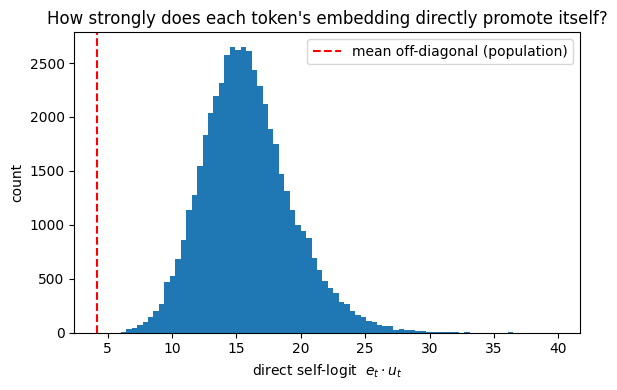

In [10]:
# --- Cheap diagonal: e_t . u_t for every token, without building the full V x V matrix ---
diag = (W_E * W_U).sum(dim=1)  # (V,) since W_U is tied and stored row-aligned with W_E

# --- Cheap population mean of the OFF-diagonal entries, also without materializing V x V ---
# sum_t sum_j e_t . u_j  =  (sum_t e_t) . (sum_j u_j)
total_sum = W_E.sum(dim=0) @ W_U.sum(dim=0)
offdiag_mean = (total_sum - diag.sum()) / (V * V - V)

print(f"mean diagonal entry   (token's direct self-logit) : {diag.mean().item():.4f}")
print(f"mean off-diagonal entry (direct logit on any other token): {offdiag_mean.item():.4f}")


plt.figure(figsize=(6, 4))
plt.hist(diag.to('cpu').numpy(), bins=80)
plt.axvline(offdiag_mean.item(), color="red", linestyle="--", label="mean off-diagonal (population)")
plt.xlabel("direct self-logit  $e_t \\cdot u_t$")
plt.ylabel("count")
plt.title("How strongly does each token's embedding directly promote itself?")
plt.legend()
plt.tight_layout()
plt.show()

If self-logits cluster well above the off-diagonal population mean, the direct path alone already
"wants" to repeat tokens — a bias the rest of the network then has to work with or against (relevant
later for [copy suppression](https://learnmechinterp.com/topics/copy-suppression/)).

Now the other direction: for a few specific tokens, which *other* tokens does the direct path favor
most? This needs one full row ($d_{\text{model}} \times V$, cheap) per token of interest, not the
whole matrix.

In [11]:
def direct_top_predictions(word, k=8, exclude_self=False):
    tid = tokenizer(word, add_special_tokens=False)["input_ids"][0]
    row = W_E[tid] @ W_U.T  # (V,) -- e_t . u_j for every j, no forward pass needed
    if exclude_self:
        row = row.clone()
        row[tid] = -float("inf")
    top = row.topk(k)
    return [(tokenizer.decode([j]), v.item()) for v, j in zip(top.values, top.indices)]

for w in [" Barack", " New", " King", " running", " iP"]:
    print(f"direct top predictions for {w!r}:")
    for tok, val in direct_top_predictions(w, exclude_self=True):
        print(f"    {tok!r:>12} : {val:.3f}")
    print()

direct top predictions for ' Barack':
         'Obama' : 9.789
        ' Obama' : 9.018
       'Hillary' : 8.486
       ' Bashar' : 8.237
    'DonaldTrump' : 8.058
       ' Lyndon' : 7.900
       ' Tayyip' : 7.791
        'Bernie' : 7.744

direct top predictions for ' New':
           'New' : 7.606
          ' NEW' : 5.799
           'NEW' : 5.431
           ' NY' : 5.326
           'new' : 5.323
    ' Manhattan' : 5.043
          ' NYC' : 5.023
          ' new' : 4.700

direct top predictions for ' King':
          'King' : 9.313
         ' king' : 7.721
         ' KING' : 7.156
        ' Queen' : 6.892
        ' Kings' : 6.826
         'Kings' : 6.694
        ' kings' : 6.677
         'Queen' : 6.641

direct top predictions for ' running':
       'running' : 7.991
      ' Running' : 7.981
       'Running' : 7.898
          ' RUN' : 6.294
          ' ran' : 6.275
          ' run' : 6.197
         ' runs' : 6.125
           'Run' : 6.039

direct top predictions for ' iP':
           ' 

Look for two kinds of pattern here: (a) trivial ones — plurals, capitalization variants, sub-word
continuations, which the embedding geometry captures almost for free — and (b) genuine semantic/factual
associations that survive with *no* attention or MLP computation at all. The mix
you get is itself evidence about what GPT-2 pushes into $W_E$ versus what it defers to later layers.

## 6. The Embedding-Only QK Circuit

Composing the embedding matrix with one attention head's query/key projections gives a token-to-token
attention-score matrix that ignores position entirely:

$$W_E \, W_Q \, W_K^T \, W_E^T$$

Entry $(a, b)$ is the embedding-only contribution to the attention score from destination token $a$ to
source token $b$. GPT-2's `c_attn` layer packs $W_Q, W_K, W_V$ for all heads into one matrix, so we
need to slice out one head's $W_Q, W_K$ first.

W_Q (per head) shape: (768, 64)  W_K (per head) shape: (768, 64)


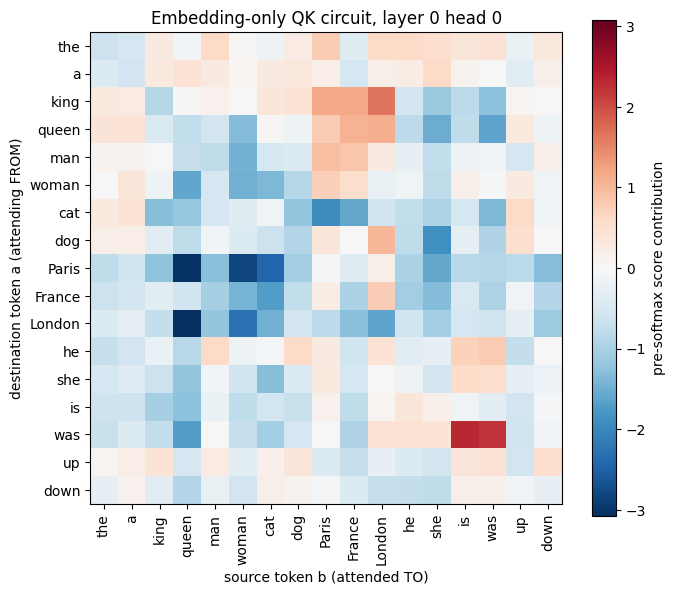

In [12]:
def get_qk_weights(model, layer, head):
    """Extract per-head W_Q, W_K (each d_model x d_head) from GPT-2's packed c_attn.

    c_attn.weight has shape (d_model, 3*d_model) and acts as y = x @ weight (HF Conv1D convention),
    packing [W_Q | W_K | W_V] side by side, each further split by head.
    """
    W_packed = model.transformer.h[layer].attn.c_attn.weight.detach()  # (d_model, 3*d_model)
    W_Q_all, W_K_all, _ = W_packed.split(d_model, dim=1)
    lo, hi = head * d_head, (head + 1) * d_head
    return W_Q_all[:, lo:hi], W_K_all[:, lo:hi]

layer, head = 0, 0
W_Q_h, W_K_h = get_qk_weights(model, layer, head)
print("W_Q (per head) shape:", tuple(W_Q_h.shape), " W_K (per head) shape:", tuple(W_K_h.shape))

# Restrict to a small, single-token vocabulary so the heatmap is legible.
words = [" the", " a", " king", " queen", " man", " woman", " cat", " dog",
         " Paris", " France", " London", " he", " she", " is", " was", " up", " down"]
sub_ids, sub_words = [], []
for w in words:
    tid = tokenizer(w, add_special_tokens=False)["input_ids"]
    if len(tid) == 1:  # keep only true single-token words
        sub_ids.append(tid[0]); sub_words.append(w.strip())

W_E_sub = W_E[sub_ids]  # (n_sub, d_model)
QK_sub = (W_E_sub @ W_Q_h @ W_K_h.T @ W_E_sub.T) / (d_head ** 0.5)  # scaled, as in real attention

plt.figure(figsize=(7, 6))
plt.imshow(QK_sub.to('cpu').numpy(), cmap="RdBu_r", vmin=-QK_sub.abs().max(), vmax=QK_sub.abs().max())
plt.xticks(range(len(sub_words)), sub_words, rotation=90)
plt.yticks(range(len(sub_words)), sub_words)
plt.xlabel("source token b (attended TO)")
plt.ylabel("destination token a (attending FROM)")
plt.title(f"Embedding-only QK circuit, layer {layer} head {head}")
plt.colorbar(label="pre-softmax score contribution")
plt.tight_layout()
plt.show()

This is the *direct*, position-free contribution only — real attention in a trained model also
depends on positional terms and, in later layers, on already-contextualized residual states rather than
bare embeddings. Try a few other `(layer, head)` pairs; early layers are the ones most likely to show
clean embedding-driven structure.

## Looking Ahead

$W_E$ tells the network *which* token is present; it says nothing about *where*. That's the subject of
[Positional Embeddings](https://learnmechinterp.com/topics/positional-embeddings/), the next topic in
this curriculum. The direct-path and QK-circuit tricks used above (cheap diagonal/row extraction,
restricting to a small legible sub-vocabulary, checking a manual computation against the model's own
forward pass) are exactly the habits that scale up to
[Direct Logit Attribution](https://learnmechinterp.com/topics/direct-logit-attribution/) and
[QK/OV circuit analysis](https://learnmechinterp.com/topics/qk-ov-circuits/) later on.

**Ideas to extend this notebook:**
- Redo Section 2 with a genuinely polysemous single-token word and more contrastive sentence pairs.
- Redo Section 6 for a middle/late layer head and see how much less "clean" the embedding-only view gets.
- Compare GPT-2's tied matrices against an *untied* model (e.g. GPT-J or a Pythia checkpoint) to see how
  $W_E$ and $W_U$ diverge geometrically once they're not forced to share parameters.
